In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from matplotlib.lines import Line2D
import seaborn as sns

from datetime import datetime as dt
from datetime import timedelta
import os

import matplotlib
import matplotlib.cm as cm
import matplotlib.ticker as ticker
pd.options.mode.chained_assignment = None 

In [2]:

def set_size(size):
    font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : size}
    matplotlib.rc('font', **font)
set_size(12)

In [3]:
folder_name = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/Figures/CompareS0S1/"

In [4]:
def read(dataset, compare):
    df = pd.read_csv(filename, header = 0)
    return df


In [5]:
def preprocess(df, p, keepAll = False):
    if 'relError' in df.columns[df.dtypes == 'object']:
        df.loc[:,'relError'] = df['relError'].apply(lambda x: x.replace(',','.')).astype({'relError': float})
    if 'epsError' in df.columns[df.dtypes == 'object']:
        df.loc[:,'epsError'] = df.loc[:,'epsError'].apply(lambda x: x.replace(',','.')).astype({'epsError': float})
    df.loc[:,'Sketch Memory (MB)'] = df.loc[:,'memUsageSynopsis']/(8e6)
    df.loc[:,'Dataset Memory (MB)'] = df.loc[:,'memUsageDataset']/(8e6)
    df.loc[:,'Speedup'] = df.loc[:,'exactTime']/df.loc[:,'estTime']
    df.loc[:,'Time Est (ms)'] =  df.loc[:,'estTime']
    df.loc[:,'Avg Update Time (ms)'] =  df.loc[:,'Avg Update Time']
    df.loc[:,'Time exact (ms)'] = df.loc[:,'exactTime']
    df.loc[:,'relMemFootprint'] = df.loc[:,'Sketch Memory (MB)']/df.loc[:,'Dataset Memory (MB)']
    df.loc[:, 'thrm33case2'] = np.where(df['setting'] != 'OmniSketch', True, df['thrm33case2'])
    df.loc[:,'RAM'] = df.loc[:,'RAM']/(8e6)
    if not keepAll:
        df = df[df['numPredicates'] == p]
    df.loc[:,'altAbsError'] = np.where(df['setting'] == 'OmniSketch',
                                       abs(df.loc[:,'case2Estimate'] - df.loc[:, 'exactAnswer']),
                                       df['absError'])
    df.loc[:, 'altEpsError'] = df['altAbsError']/df['streamSize'] # Alternative epsError.
    df.loc[:,'altNullAbsError'] = np.where(df['thrm33case2'] == False,
                                           df.loc[:,'exactAnswer'],
                                           abs(df.loc[:,'estimate'] - df.loc[:,'exactAnswer']))
    df.loc[:, 'altNullEpsError'] = df['altNullAbsError']/df['streamSize']
    df['d'] = 0
    df['w'] = 0
    df['B'] = 0
    df['b'] = 0
    for k, v in df.iterrows():
        pars = [int(i) for i in list(v['parameters'].replace("[", "").replace("]", "").split(", "))]
        if v['setting'] == "OmniSketch":
            df.loc[k, 'd'] = pars[0]
            df.loc[k, 'w'] = pars[1]
            df.loc[k, 'B'] = pars[2]
            df.loc[k, 'b'] = pars[3]
    
    df['histSetting'] = (df['setting'] + df['RAM'].astype(str))
    for i, v in df.iterrows():
        setting = v['histSetting'].replace("p0.0", "p").replace("n0.0", "n").replace(".0", "")
        if (setting == 'Sketch0Cap'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}0_{\cap}$'
        elif (setting == 'Sketch0Min'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}0_{\min}$'
        elif (setting == 'OmniSketch1'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (1 MB)$'
        elif (setting == 'OmniSketch10'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (10 MB)$'
        elif (setting == 'OmniSketch50'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (50 MB)$'
        elif (setting == 'OmniSketch100'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (100 MB)$'
        elif (setting == 'OmniSketch200'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (200 MB)$'
        elif (setting == 'Hydra1'):
            df.loc[i, 'histSetting'] =  r'Hydra (1 MB)'
        elif (setting == 'Hydra10'):
            df.loc[i, 'histSetting'] =  r'Hydra (10 MB)'
        elif (setting == 'Hydra50'):
            df.loc[i, 'histSetting'] =  r'Hydra (50 MB)'
        elif (setting == 'Hydra100'):
            df.loc[i, 'histSetting'] =  r'Hydra (100 MB)'
        elif (setting == 'Hydra200'):
            df.loc[i, 'histSetting'] =  r'Hydra (200 MB)'
        else:
            print(setting)

    return df

In [6]:
dataset = "SNMP"

In [7]:

# Define a dictionary to map 'histSetting' to marker and color
histSetting_style_dict = {
    '$\\mathbb{S}0_{\\min}$': {'marker': 'o', 'color': 'blue', 'linestyle': '-'},
    '$\\mathbb{S}0_{\\cap}$': {'marker': 's', 'color': 'green', 'linestyle': '--'},
    '$\\mathbb{S}1 (1 MB)$': {'marker': '^', 'color': 'yellow', 'linestyle': '-'},
    '$\\mathbb{S}1 (10 MB)$': {'marker': '^', 'color': 'orange', 'linestyle': '-'},
    '$\\mathbb{S}1 (50 MB)$': {'marker': 'D', 'color': 'red', 'linestyle': '-'},
    '$\\mathbb{S}1 (100 MB)$': {'marker': 'v', 'color': 'purple', 'linestyle': '-'},
    '$\\mathbb{S}1 (200 MB)$': {'marker': '*', 'color': 'black', 'linestyle': '-'},
    'Hydra (1 MB)': {'marker': 'X', 'color': 'lime', 'linestyle': '-.'},
    'Hydra (10 MB)': {'marker': 'X', 'color': 'lime', 'linestyle': '-.'},
    'Hydra (50 MB)': {'marker': '+', 'color': 'blue', 'linestyle': '-.'},
    'Hydra (100 MB)': {'marker': 'P', 'color': 'deeppink', 'linestyle': '-.'},
    'Hydra (200 MB)': {'marker': 'H', 'color': 'grey', 'linestyle': '-.'},
    'OmniSketch_2': {'marker': 'D', 'color': 'brown', 'linestyle': ':'},
    'OmniSketch_3': {'marker': 's', 'color': 'darkblue', 'linestyle': '-.'},
    'Hydra_2': {'marker': 'o', 'color': 'teal', 'linestyle': '-'},
    'Hydra_3': {'marker': 'v', 'color': 'indigo', 'linestyle': '--'},
    'OmniSketch_2_50': {'marker': 'X', 'color': 'gold', 'linestyle': '-.'},
    'OmniSketch_3_50': {'marker': 'P', 'color': 'pink', 'linestyle': ':'},
    'Hydra_2_50': {'marker': 's', 'color': 'darkgreen', 'linestyle': '-'},
    'Hydra_3_50': {'marker': '*', 'color': 'coral', 'linestyle': '--'},
    'OmniSketch_2_100': {'marker': 'D', 'color': 'lavender', 'linestyle': '-.'},
    'OmniSketch_3_100': {'marker': 'H', 'color': 'chocolate', 'linestyle': ':'},
    'Hydra_2_100': {'marker': '^', 'color': 'gold', 'linestyle': '-'},
    'Hydra_3_100': {'marker': 'o', 'color': 'darkred', 'linestyle': '--'},
    'Hydra_4': {'marker': 'X', 'color': 'darkcyan', 'linestyle': '-.'},
    'OmniSketch_4': {'marker': 'D', 'color': 'deeppink', 'linestyle': ':'},
    'Hydra_4_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-'},
    'OmniSketch_4_50': {'marker': 'H', 'color': 'crimson', 'linestyle': '--'},
    'Hydra_4_100': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-.'},
    'OmniSketch_4_100': {'marker': 'v', 'color': 'hotpink', 'linestyle': ':'},
    'Hydra_5': {'marker': 'X', 'color': 'darkcyan', 'linestyle': '-'},
    'OmniSketch_5': {'marker': 'D', 'color': 'deeppink', 'linestyle': '--'},
    'Hydra_5_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-.'},
    'OmniSketch_5_50': {'marker': 'H', 'color': 'crimson', 'linestyle': ':'},
    'Hydra_5_100': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-'},
    'OmniSketch_5_100': {'marker': 'v', 'color': 'hotpink', 'linestyle': '--'},
    'Hydra_6': {'marker': 'X', 'color': 'black', 'linestyle': '-.'},
    'OmniSketch_6': {'marker': 'D', 'color': 'gray', 'linestyle': ':'},
    'Hydra_6_50': {'marker': '+', 'color': 'darkblue', 'linestyle': '-'},
    'OmniSketch_6_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_6_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-.'},
    'OmniSketch_6_100': {'marker': 'v', 'color': 'darkcyan', 'linestyle': ':'},
    'Hydra_7': {'marker': '^', 'color': 'lime', 'linestyle': '-'},
    'OmniSketch_7': {'marker': 'D', 'color': 'indigo', 'linestyle': '--'},
    'Hydra_7_50': {'marker': 'X', 'color': 'crimson', 'linestyle': '-.'},
    'OmniSketch_7_50': {'marker': 'H', 'color': 'gold', 'linestyle': ':'},
    'Hydra_7_100': {'marker': 'P', 'color': 'deeppink', 'linestyle': '-'},
    'OmniSketch_7_100': {'marker': 'v', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_8': {'marker': 'o', 'color': 'brown', 'linestyle': '-.'},
    'OmniSketch_8': {'marker': 's', 'color': 'darkblue', 'linestyle': ':'},
    'Hydra_8_50': {'marker': '+', 'color': 'darkgreen', 'linestyle': '-'},
    'OmniSketch_8_50': {'marker': 'H', 'color': 'coral', 'linestyle': '--'},
    'Hydra_8_100': {'marker': 'P', 'color': 'lavender', 'linestyle': '-.'},
    'OmniSketch_8_100': {'marker': 'v', 'color': 'chocolate', 'linestyle': ':'},
    'Hydra_9': {'marker': '^', 'color': 'gold', 'linestyle': '-'},
    'OmniSketch_9': {'marker': 'D', 'color': 'crimson', 'linestyle': '--'},
    'Hydra_9_50': {'marker': 'X', 'color': 'darkblue', 'linestyle': '-.'},
    'OmniSketch_9_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': ':'},
    'Hydra_9_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-'},
    'OmniSketch_9_100': {'marker': 'v', 'color': 'darkcyan', 'linestyle': '--'},
    'Hydra_10': {'marker': 'o', 'color': 'black', 'linestyle': '-.'},
    'OmniSketch_10': {'marker': 's', 'color': 'gray', 'linestyle': ':'},
    'Hydra_10_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-'},
    'OmniSketch_10_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_10_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-.'},
    'OmniSketch_10_100': {'marker': 'v', 'color': 'deeppink', 'linestyle': ':'}
}

# Define a dictionary to map 'aggr' to linestyle
aggr_dict = {
    'altEpsError': '-',
    'IT': '-',
    'execTime': ':',
    
    'RAM': 'dotted'
}

# Get the unique MB values from the 'histSetting' column
#unique_MB_values = [int(x.split(' ')[1].replace('(', '')) for x in df['histSetting'] if 'MB' in x]

# Calculate the normalized values for the color map
#normalized_MB = [(MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values)) for MB in unique_MB_values]



# Function to get color based on 'histSetting'
def get_color(histSetting, psetting = False):
    if psetting:
        if 'Hydra' in histSetting:
        # Create a color map based on the MB values
            color_map = cm.get_cmap('plasma')
        elif 'Omni' in histSetting:
            color_map = cm.get_cmap('cividis')
        else:
            print("No colormap defined for setting {}".format(histSetting))
        p = int(histSetting.split('_')[1].replace('_', ''))
        normalized_p_value = (p - 2) / (1)
        return color_map(normalized_p_value)
    
    if '{S}0' in histSetting:
        return histSetting_style_dict.get(histSetting)['color']
    if 'Hydra' in histSetting:
        # Create a color map based on the MB values
        color_map = cm.get_cmap('tab20')
    elif '{S}1' in histSetting:
        color_map = cm.get_cmap('viridis')
    else:
        print("No colormap defined for setting {}".format(histSetting))
    MB = int(histSetting.split(' ')[1].replace('(', ''))
    normalized_MB_value = (MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values))
    return color_map(normalized_MB_value)


# Compare scaling

In [8]:
#filename = "output/results_Compare Estimators_CAIDA_2023-07-14.csv"
filename = "outputODC/compare estimators/newest/results_Compare Estimators_SNMP_2023-08-24_Rep5.csv"
df = read(dataset, True)
p = 2
df = preprocess(df, p, True)

['$\\mathbb{S}0$', '$\\mathbb{S}1 (10 MB)$', '$\\mathbb{S}1 (100 MB)$', '$\\mathbb{S}1 (200 MB)$', '$\\mathbb{S}1 (50 MB)$']
$\mathbb{S}0$
$\mathbb{S}1 (10 MB)$
$\mathbb{S}1 (50 MB)$
$\mathbb{S}1 (100 MB)$
$\mathbb{S}1 (200 MB)$


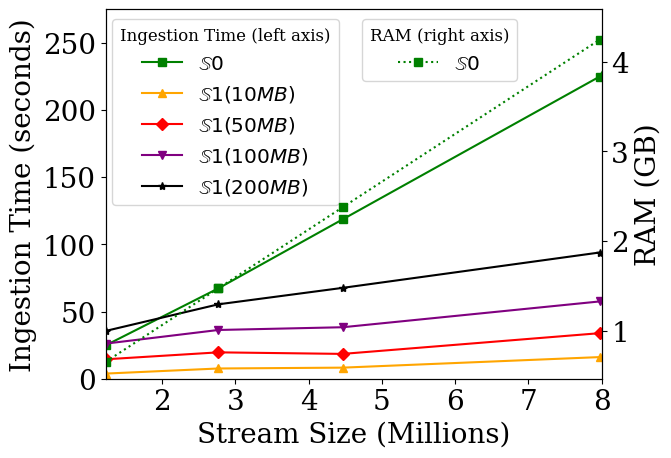

In [19]:
def extract_x_from_setting(setting):
    if 'MB' in setting:
        return int(setting.split(' (')[1].split(' MB)')[0])
    else:
        return 0
def create_custom_plot(df):
    df1 = df[df['RAM'] != 1]
    subset_df = df1[['histSetting', 'streamSize', 'Avg Update Time', 'Sketch Memory (MB)']]
    
    # Aggregate data by unique histSetting and streamSize
    aggregated_df = subset_df.groupby(['histSetting', 'streamSize'], as_index=False).agg({'Avg Update Time': 'mean', 'Sketch Memory (MB)': 'mean'})
    
    fig, ax1 = plt.subplots()
    ax1.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
    
    legend_handles_ax1 = {}
    legend_labels_ax1 = []    
    histSettings = aggregated_df['histSetting'].unique()
    for histSetting in histSettings:
        if '{S}0_{\min}' in histSetting:
            continue
    
        style = histSetting_style_dict.get(histSetting, {'marker': 'o'})
        hist_subset_df = aggregated_df[aggregated_df['histSetting'] == histSetting]
    
        line1, = ax1.plot(hist_subset_df['streamSize'],
                          hist_subset_df['Avg Update Time']*hist_subset_df['streamSize']/1000,
                          linestyle=aggr_dict['IT'],
                          color=style['color'],
                          marker=style['marker'])
    
        
        if '{S}0' in histSetting:
            legend_labels_ax1.append('$\mathbb{S}0$')
            legend_handles_ax1['$\mathbb{S}0$'] = line1
        else:
            legend_handles_ax1[f'{histSetting}'] = line1
            legend_labels_ax1.append(f'{histSetting}')
            
    
    
    
    ax2 = ax1.twinx()
    ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
    
    legend_handles_ax2 = []
    legend_labels_ax2 = []
    
    for histSetting in histSettings:
        if histSetting == '$\\mathbb{S}0_{\\cap}$':
            style = histSetting_style_dict.get(histSetting, {'marker': 'o'})
            hist_subset_df = aggregated_df[aggregated_df['histSetting'] == histSetting]

            line2, = ax2.plot(hist_subset_df['streamSize'],
                              hist_subset_df['Sketch Memory (MB)']/1000,
                              linestyle=aggr_dict['RAM'],
                              color=style['color'],
                              marker=style['marker'])
    
            legend_handles_ax2.append(line2)
            legend_labels_ax2.append('$\mathbb{S}0$')
    
    
    #legend_handles = legend_handles_ax1 + legend_handles_ax2
    #legend_labels = legend_labels_ax1 + legend_labels_ax2
    
    lines = []
    labels_ax1 = []
    print(legend_labels_ax1)
    for setting in sorted(legend_labels_ax1, key=extract_x_from_setting):
        print(setting)
        line = legend_handles_ax1[setting]
        lines.append(line)
        labels_ax1.append(setting)
    font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 12}

    matplotlib.rc('font', **font)
    ax1.legend(lines, labels_ax1,
               title="Ingestion Time (left axis)", bbox_to_anchor=(0.49, 1), fontsize='large')
    ax2.legend(legend_handles_ax2, legend_labels_ax2,
               title="RAM (right axis)", bbox_to_anchor=(0.85, 1), fontsize='large')
    font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 20}

    matplotlib.rc('font', **font)
    ax1.set_xlabel('Stream Size (Millions)')
    ax1.set_ylabel('Ingestion Time (seconds)')
    
    ax2.set_ylabel('RAM (GB)')
    
    ax1.set_ylim(0, 275)
    ax1.set_xlim(aggregated_df['streamSize'].min(), 8e6)
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(base=1e6))
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}'))
    
    plt.show()
    fig.savefig(folder_name + "{}_{}.pdf".format("Compare_Estimators_Scaling", dataset), format="pdf", bbox_inches="tight")

# Call the function with your DataFrame as input
create_custom_plot(df)

# Scaling of only S1

In [11]:
filename = "outputODC/Scalability/newest/results_Scalability_CAIDA_2023-08-22_Rep5.csv"
dataset = "CAIDA"
dfsc = read(dataset, True)
p = 2
dfsc = preprocess(dfsc, p, True)



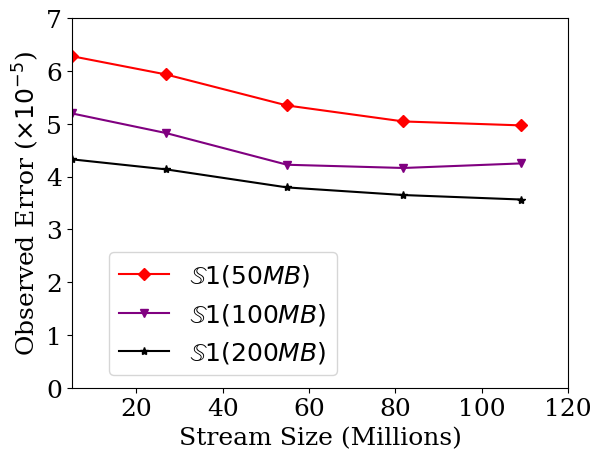

In [31]:
set_size(18)
import matplotlib.ticker as ticker
dfs = dfsc[dfsc['setting'] == 'OmniSketch']

grouped_df = dfs.groupby(['histSetting', 'streamSize'])['altEpsError'].mean().reset_index()

# Set up the plot
fig, ax = plt.subplots()
ord_settings = ['$\\mathbb{S}1 (50 MB)$', '$\\mathbb{S}1 (100 MB)$', '$\\mathbb{S}1 (200 MB)$']
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 15}
ax.set_xlabel('Stream Size (Millions)')
# Iterate over unique histSettings
#for hist_setting in grouped_df['histSetting'].unique():
for hist_setting in ord_settings:

# Filter the data for the current histSetting
    style = histSetting_style_dict.get(hist_setting, {'marker': 'o'})
    filtered_data = grouped_df[grouped_df['histSetting'] == hist_setting]

    # Plot the data
    ax.plot(filtered_data['streamSize'], filtered_data['altEpsError'],
            linestyle=aggr_dict['altEpsError'],
            color=style['color'],
            marker=style['marker'], label=hist_setting)

# Set labels and title

#ax.set_title('Avg. abs error / N vs streamSize for sketch 1')

# Add a legend
ax.legend(loc='upper left', bbox_to_anchor=(0.05,0.4))
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 25}
ax.set_xlabel('Stream Size (Millions)')
ax.set_ylabel('Observed Error ({})'.format(r'$\times 10^{-5}$'))
# Set x-axis range from 0.5e7 to 2e7
ax.set_xlim(5077343, 1.2e8)
ax.set_ylim(0, 7e-5)
#plt.xticks(range(x_ticks[0], x_ticks[-1]))
# Set x-axis ticker and formatter
#ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.xaxis.set_major_formatter(ticker.MultipleLocator(base=1e6))
#ticker.MultipleLocator(base=1e6)
#plt.xticks(range(1000000, 8000000))
#ax.set_ylim(0, 3.5e-4)
#ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.yaxis.set_major_formatter()
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1e-5))  # Set ticks at every 1e6
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e-5)}'))
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=2e7))  # Set ticks at every 1e6
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}'))
#ax.text(1.2e8, 0, '$\cdot 10^7$', fontsize=10, color='black', ha='right', va='top')  # Add custom annotation at bottom right

fig.savefig(folder_name + "{}_{}.pdf".format("Scale_Sketch1", dataset), format="pdf", bbox_inches="tight" )


# Display the plot
plt.show()

In [19]:
dfsc['streamSize'].unique()

array([  5077343,  26874162,  54925094,  81867866, 109222227], dtype=int64)

In [68]:
dfsc.columns

Index(['streamSize', 'numAttributes', 'memUsageDataset', 'RAM', 'setting',
       'Avg Update Time', 'memUsageSynopsis', 'parameters',
       'numAttributesInWorkload', 'queryID', 'numPredicates', 'exactAnswer',
       'estimate', 'absError', 'relError', 'epsError', 'withinThreshold',
       'estTime', 'queryText', 'exactTime', 'intersectSize', 'bound',
       'thrm33case2', 'case2Estimate', 'zeroEstimate', 'condition', 'queryBin',
       'Sketch Memory (MB)', 'Dataset Memory (MB)', 'Speedup', 'Time Est (ms)',
       'Avg Update Time (ms)', 'Time exact (ms)', 'relMemFootprint',
       'altAbsError', 'altEpsError', 'altNullAbsError', 'altNullEpsError', 'd',
       'w', 'B', 'b', 'histSetting'],
      dtype='object')

In [69]:
dfs

,streamSize,numAttributes,memUsageDataset,RAM,setting,Avg Update Time,memUsageSynopsis,parameters,numAttributesInWorkload,queryID,...,relMemFootprint,altAbsError,altEpsError,altNullAbsError,altNullEpsError,d,w,B,b,histSetting
0,5077343,6,1137324832,10.0,OmniSketch,0.001382,79833600,"[3, 8, 4544, 25]",11,4,...,0.070194,1231.0,2.424496e-04,4177.0,8.226744e-04,3,8,4544,25,$\mathbb{S}1 (10 MB)$
1,5077343,6,1137324832,10.0,OmniSketch,0.001382,79833600,"[3, 8, 4544, 25]",11,5,...,0.070194,667.0,1.313679e-04,4177.0,8.226744e-04,3,8,4544,25,$\mathbb{S}1 (10 MB)$
2,5077343,6,1137324832,10.0,OmniSketch,0.001382,79833600,"[3, 8, 4544, 25]",11,7,...,0.070194,54.0,1.063548e-05,4177.0,8.226744e-04,3,8,4544,25,$\mathbb{S}1 (10 MB)$
3,5077343,6,1137324832,10.0,OmniSketch,0.001382,79833600,"[3, 8, 4544, 25]",11,8,...,0.070194,1766.0,3.478197e-04,10970.0,2.160579e-03,3,8,4544,25,$\mathbb{S}1 (10 MB)$
4,5077343,6,1137324832,10.0,OmniSketch,0.001382,79833600,"[3, 8, 4544, 25]",11,9,...,0.070194,1231.0,2.424496e-04,4177.0,8.226744e-04,3,8,4544,25,$\mathbb{S}1 (10 MB)$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52424,81867866,6,18338401984,200.0,OmniSketch,0.002331,1591041718,"[3, 8, 84992, 33]",11,8329,...,0.086760,132.0,1.612354e-06,56.0,6.840291e-07,3,8,84992,33,$\mathbb{S}1 (200 MB)$
52425,81867866,6,18338401984,200.0,OmniSketch,0.002331,1591041718,"[3, 8, 84992, 33]",11,8330,...,0.086760,54.0,6.595995e-07,54.0,6.595995e-07,3,8,84992,33,$\mathbb{S}1 (200 MB)$
52426,81867866,6,18338401984,200.0,OmniSketch,0.002331,1591041718,"[3, 8, 84992, 33]",11,8331,...,0.086760,58.0,7.084587e-07,58.0,7.084587e-07,3,8,84992,33,$\mathbb{S}1 (200 MB)$
52427,81867866,6,18338401984,200.0,OmniSketch,0.002331,1591041718,"[3, 8, 84992, 33]",11,8332,...,0.086760,54.0,6.595995e-07,54.0,6.595995e-07,3,8,84992,33,$\mathbb{S}1 (200 MB)$


In [70]:
dfs.groupby(['histSetting', 'streamSize', 'RAM', 'B', 'b', 'd', 'w', 'memUsageSynopsis', 'numAttributes'])[['altEpsError', 'intersectSize', 'case2Estimate']].mean().reset_index()

,histSetting,streamSize,RAM,B,b,d,w,memUsageSynopsis,numAttributes,altEpsError,intersectSize,case2Estimate
0,$\mathbb{S}1 (10 MB)$,5077343,10.0,4544,25,3,8,79833600,6,0.000109,22.666162,4374.401634
1,$\mathbb{S}1 (10 MB)$,26874162,10.0,4544,25,3,8,77792174,6,0.000135,19.921308,20386.416465
2,$\mathbb{S}1 (10 MB)$,54925094,10.0,4544,25,3,8,72564352,6,0.000267,22.005448,45847.776029
3,$\mathbb{S}1 (10 MB)$,81867866,10.0,4544,25,3,8,67684230,6,0.000470,26.360169,80935.225787
4,$\mathbb{S}1 (100 MB)$,5077343,100.0,43008,31,3,8,792728064,6,0.000046,215.126816,4386.235775
5,$\mathbb{S}1 (100 MB)$,26874162,100.0,43008,31,3,8,792727040,6,0.000042,174.234564,18784.789952
6,$\mathbb{S}1 (100 MB)$,54925094,100.0,43008,31,3,8,792723840,6,0.000041,154.126816,33860.108959
7,$\mathbb{S}1 (100 MB)$,81867866,100.0,43008,31,3,8,792720640,6,0.000036,144.142554,46800.880751
8,$\mathbb{S}1 (200 MB)$,5077343,200.0,84992,33,3,8,1591054848,6,0.000038,425.144976,4386.573547
9,$\mathbb{S}1 (200 MB)$,26874162,200.0,84992,33,3,8,1591052248,6,0.000038,345.224879,18830.235169


In [45]:
dfs.columns

Index(['streamSize', 'numAttributes', 'memUsageDataset', 'RAM', 'setting',
       'Avg Update Time', 'memUsageSynopsis', 'parameters',
       'numAttributesInWorkload', 'queryID', 'numPredicates', 'exactAnswer',
       'estimate', 'absError', 'relError', 'epsError', 'withinThreshold',
       'estTime', 'queryText', 'exactTime', 'intersectSize', 'bound',
       'thrm33case2', 'case2Estimate', 'zeroEstimate', 'condition', 'queryBin',
       'Sketch Memory (MB)', 'Dataset Memory (MB)', 'Speedup', 'Time Est (ms)',
       'Avg Update Time (ms)', 'Time exact (ms)', 'relMemFootprint',
       'altAbsError', 'altEpsError', 'altNullAbsError', 'altNullEpsError', 'd',
       'w', 'B', 'b', 'histSetting'],
      dtype='object')

In [50]:
3*8*6*(32+22016*(30+1+3*32))

402633216

In [54]:
for i in dfsc['streamSize'].unique():
    df50 = dfsc[dfsc['RAM'] == 50]
    dfi = df50[df50['streamSize'] == i]
    print(dfi[dfi['altEpsError'] == dfi['altEpsError'].max()]['queryID'])

5010    4846
Name: queryID, dtype: int64
18226    4846
Name: queryID, dtype: int64
31442    4846
Name: queryID, dtype: int64
44658    4846
Name: queryID, dtype: int64


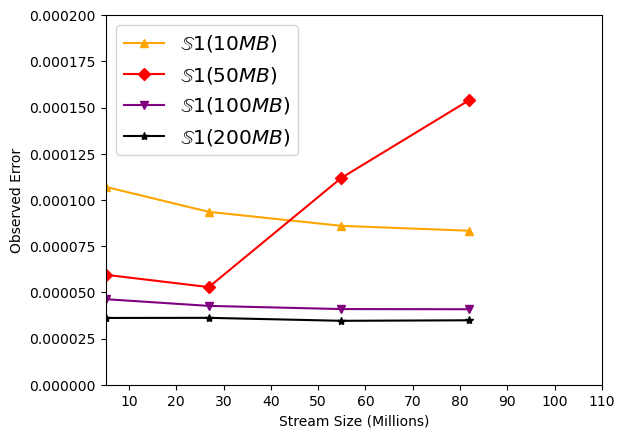

In [35]:
import matplotlib.ticker as ticker
dfs = dfsc[dfsc['setting'] == 'OmniSketch']
#dfs = dfs[dfs['numAttributes'] == dfs['numAttributes'].max()]
# Calculate average altEpsError per histSetting and streamSize
grouped_df = dfs.groupby(['histSetting', 'streamSize'])['altEpsError'].mean().reset_index()

# Set up the plot
fig, ax = plt.subplots()
ord_settings = ['$\\mathbb{S}1 (10 MB)$', '$\\mathbb{S}1 (50 MB)$', '$\\mathbb{S}1 (100 MB)$', '$\\mathbb{S}1 (200 MB)$']

# Iterate over unique histSettings
#for hist_setting in grouped_df['histSetting'].unique():
for hist_setting in ord_settings:

# Filter the data for the current histSetting
    style = histSetting_style_dict.get(hist_setting, {'marker': 'o'})
    filtered_data = grouped_df[grouped_df['histSetting'] == hist_setting]

    # Plot the data
    ax.plot(filtered_data['streamSize'], filtered_data['altEpsError'],
            linestyle=aggr_dict['altEpsError'],
            color=style['color'],
            marker=style['marker'], label=hist_setting)

# Set labels and title
ax.set_xlabel('Stream Size (Millions)')
ax.set_ylabel('Observed Error')
#ax.set_title('Avg. abs error / N vs streamSize for sketch 1')

# Add a legend
ax.legend(loc='upper left', fontsize='x-large')

# Set x-axis range from 0.5e7 to 2e7
ax.set_xlim(5077343, 1.1e8)
ax.set_ylim(0, 2e-4)
#plt.xticks(range(x_ticks[0], x_ticks[-1]))
# Set x-axis ticker and formatter
#ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.xaxis.set_major_formatter(ticker.MultipleLocator(base=1e6))
#ticker.MultipleLocator(base=1e6)
#plt.xticks(range(1000000, 8000000))
#ax.set_ylim(0, 3.5e-4)
#ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.yaxis.set_major_formatter()
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1e7))  # Set ticks at every 1e6
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}'))
#ax.text(1.2e8, 0, '$\cdot 10^7$', fontsize=10, color='black', ha='right', va='top')  # Add custom annotation at bottom right

fig.savefig(folder_name + "{}_{}.pdf".format("Scale_Sketch1", dataset), format="pdf", bbox_inches="tight" )


# Display the plot
plt.show()

In [49]:
old_df = dfsc

In [37]:
df50 = dfsc[dfsc['RAM'] == 50]

In [55]:
df50 = old_df[old_df['RAM'] == 50]
for i in old_df['streamSize'].unique():
    dfi = old_df[old_df['streamSize'] == i]
    print(dfi[dfi['altEpsError'] == dfi['altEpsError'].max()]['queryID'])

1706    4846
Name: queryID, dtype: int64
14922    4846
Name: queryID, dtype: int64
31442    4846
Name: queryID, dtype: int64
44658    4846
Name: queryID, dtype: int64


In [57]:
q = dfsc[dfsc['queryID'] == 4846] 

In [63]:
q['queryText']

1706     ipSrcNet = 241121 and ipDstNet = 195200
5010     ipSrcNet = 241121 and ipDstNet = 195200
8314     ipSrcNet = 241121 and ipDstNet = 195200
11618    ipSrcNet = 241121 and ipDstNet = 195200
14922    ipSrcNet = 241121 and ipDstNet = 195200
18226    ipSrcNet = 241121 and ipDstNet = 195200
21530    ipSrcNet = 241121 and ipDstNet = 195200
24834    ipSrcNet = 241121 and ipDstNet = 195200
28138    ipSrcNet = 241121 and ipDstNet = 195200
31442    ipSrcNet = 241121 and ipDstNet = 195200
34746    ipSrcNet = 241121 and ipDstNet = 195200
38050    ipSrcNet = 241121 and ipDstNet = 195200
41354    ipSrcNet = 241121 and ipDstNet = 195200
44658    ipSrcNet = 241121 and ipDstNet = 195200
47962    ipSrcNet = 241121 and ipDstNet = 195200
51266    ipSrcNet = 241121 and ipDstNet = 195200
Name: queryText, dtype: object

In [67]:
grouped_df = dfs.groupby(['histSetting', 'streamSize'])['altEpsError'].mean().reset_index()

In [68]:
grouped_df

,histSetting,streamSize,altEpsError
0,$\mathbb{S}1 (10 MB)$,5077343,0.000107
1,$\mathbb{S}1 (10 MB)$,26874162,0.000094
2,$\mathbb{S}1 (10 MB)$,54925094,0.000086
3,$\mathbb{S}1 (10 MB)$,81867866,0.000083
4,$\mathbb{S}1 (100 MB)$,5077343,0.000046
5,$\mathbb{S}1 (100 MB)$,26874162,0.000043
6,$\mathbb{S}1 (100 MB)$,54925094,0.000041
7,$\mathbb{S}1 (100 MB)$,81867866,0.000041
8,$\mathbb{S}1 (200 MB)$,5077343,0.000036
9,$\mathbb{S}1 (200 MB)$,26874162,0.000036


In [64]:
q[['RAM','case2Estimate', 'altEpsError']]

,RAM,case2Estimate,altEpsError
1706,10.0,44562.0,0.007447
5010,50.0,43120.0,0.007163
8314,100.0,42618.0,0.007064
11618,200.0,43008.0,0.007141
14922,10.0,260915.0,0.008305
18226,50.0,233042.0,0.007268
21530,100.0,244717.0,0.007702
24834,200.0,247175.0,0.007793
28138,10.0,501140.0,0.007689
31442,50.0,520319.0,0.008038


In [59]:
q['intersectSize']

1706      154.0
5010      722.0
8314     1394.0
11618    2780.0
14922     171.0
18226     740.0
21530    1518.0
24834    3030.0
28138     164.0
31442     825.0
34746    1611.0
38050    3048.0
41354     181.0
44658     839.0
47962    1619.0
51266    3100.0
Name: intersectSize, dtype: float64

In [58]:
q['exactAnswer'].unique()

array([  6753.,  37733.,  78820., 121474.])

In [23]:
filename = "outputODC/Scalability/Repetition 1/results_Scalability_CAIDA_2023-08-03_Rep7.csv"

In [24]:
dfsc7 = read(dataset, True)
p = 2
dfsc7 = preprocess(dfsc7, p, True)



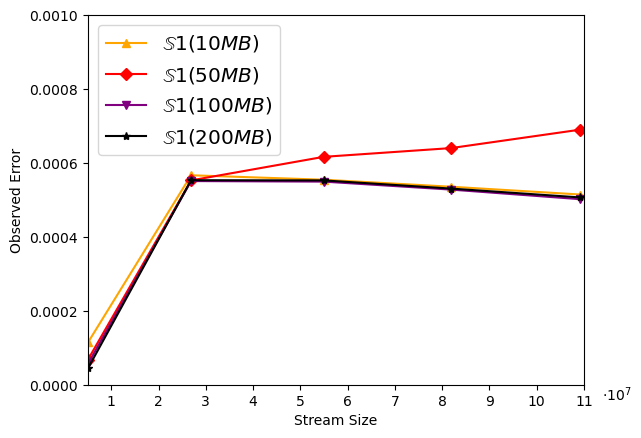

In [25]:
import matplotlib.ticker as ticker
dfs = dfsc7[dfsc7['setting'] == 'OmniSketch']
#dfs = dfs[dfs['numAttributes'] == dfs['numAttributes'].max()]
# Calculate average altEpsError per histSetting and streamSize
grouped_df = dfs.groupby(['histSetting', 'streamSize'])['altEpsError'].mean().reset_index()

# Set up the plot
fig, ax = plt.subplots()
ord_settings = ['$\\mathbb{S}1 (10 MB)$', '$\\mathbb{S}1 (50 MB)$', '$\\mathbb{S}1 (100 MB)$', '$\\mathbb{S}1 (200 MB)$']

# Iterate over unique histSettings
#for hist_setting in grouped_df['histSetting'].unique():
for hist_setting in ord_settings:

# Filter the data for the current histSetting
    style = histSetting_style_dict.get(hist_setting, {'marker': 'o'})
    filtered_data = grouped_df[grouped_df['histSetting'] == hist_setting]

    # Plot the data
    ax.plot(filtered_data['streamSize'], filtered_data['altEpsError'],
            linestyle=aggr_dict['altEpsError'],
            color=style['color'],
            marker=style['marker'], label=hist_setting)

# Set labels and title
ax.set_xlabel('Stream Size')
ax.set_ylabel('Observed Error')
#ax.set_title('Avg. abs error / N vs streamSize for sketch 1')

# Add a legend
ax.legend(loc='upper left', fontsize='x-large')

# Set x-axis range from 0.5e7 to 2e7
ax.set_xlim(5077343, 1.1e8)
ax.set_ylim(0, 1e-3)
#plt.xticks(range(x_ticks[0], x_ticks[-1]))
# Set x-axis ticker and formatter
#ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.xaxis.set_major_formatter(ticker.MultipleLocator(base=1e6))
#ticker.MultipleLocator(base=1e6)
#plt.xticks(range(1000000, 8000000))
#ax.set_ylim(0, 3.5e-4)
#ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.yaxis.set_major_formatter()
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1e7))  # Set ticks at every 1e6
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e7)}'))
ax.text(1.2e8, 0, '$\cdot 10^7$', fontsize=10, color='black', ha='right', va='top')  # Add custom annotation at bottom right

fig.savefig(folder_name + "{}_{}.pdf".format("Scale_Sketch1", dataset), format="pdf", bbox_inches="tight" )


# Display the plot
plt.show()

In [18]:
dfsc['streamSize'].max()

81867866

In [19]:
dfsc_1 = dfsc[dfsc['streamSize'] == dfsc['streamSize'].min()]
dfsc_2 = dfsc[dfsc['streamSize'] == dfsc['streamSize'].max()]

In [25]:
dfsc_1['exactAnswer'].iloc[342]

140059.0

In [24]:
dfsc_2['exactAnswer'].iloc[342]

1620970.0

In [66]:
qs = pd.read_csv('C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/output/queries__CAIDA.csv')

In [76]:
for i in qs['predicates'].unique():
    if '6' in i:
        print(i)

[6, 7]
[6, 7, 8]
[6, 7, 8, 10]
[6, 7, 9]
[6, 7, 9, 10]
[6, 7, 10]
[6, 8]
[6, 8, 10]
[6, 9]
[6, 9, 10]
[6, 10]
